In [1]:
import os
from pathlib import Path
import numpy as np
from tqdm import tqdm
import pandas as pd
import plotly.graph_objects as go
from Bio.PDB import PDBParser
import py3Dmol
import networkx as nx
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import pandas as pd
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import torch
import torch.nn.functional as F
from torch_geometric.data import Data

from torch_geometric.utils import to_networkx
from torch_geometric.loader import DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
import xgboost as xgb


from mdm2_breaker import ProteinFeaturizer, SmallMoleculeFeaturizer, SmallMoleculeFeaturizer_v2
from mdm2_breaker.models import GraphSiameseNetwork, GraphSiameseNetwork_v2

ROOT = Path(os.getcwd()).parents[0]

In [2]:
pdb_file = os.path.join(ROOT, "data", "MDM2_Breaker", "raw", "1YCR.pdb")
mol_file = os.path.join(ROOT, "data", "MDM2_Breaker", "raw", "bindingdb_p53_binding_protein_mdm2.tsv")

## Utility Functions

In [3]:
def view_protein(pdb_file, highlight_chain="A"):
    view = py3Dmol.view(query=pdb_file)

    # Show the whole protein as a "Cartoon" (Ribbon)
    view.setStyle({"cartoon": {"color": "spectrum"}})

    # Show the Alpha Carbons as spheres
    view.addStyle(
        {"chain": highlight_chain, "atom": "CA"},
        {"sphere": {"radius": 0.5, "color": "red"}},
    )

    view.zoomTo()
    view.show()

In [4]:
def visualize_graph(data, title="Molecule Graph"):
    # 1. Convert PyG Data to NetworkX
    # to_undirected ensures we don't draw two arrows for every bond
    G = to_networkx(data, to_undirected=True)
    
    # 2. Map the "Node Features" back to Element Names
    # Your allowed_atoms list from the featurizer:
    atom_map = {0: 'C', 1: 'N', 2: 'O', 3: 'F', 4: 'S', 5: 'Cl', 6: 'Br', 7: 'I', 8: '?'}
    
    # Create labels and colors for the plot
    labels = {}
    node_colors = []
    
    for node_idx in G.nodes():
        # Get the feature index from the tensor
        # data.x[node_idx] is a tensor like [0], we need the integer 0
        feat_idx = data.x[node_idx].item()
        
        element = atom_map.get(feat_idx, '?')
        labels[node_idx] = f"{node_idx}:{element}" # Format: "Index:Element"
        
        # Color logic (CPK-ish coloring)
        if element == 'C': node_colors.append('gray')
        elif element == 'N': node_colors.append('blue')
        elif element == 'O': node_colors.append('red')
        elif element == 'S': node_colors.append('yellow')
        elif element == 'Cl': node_colors.append('lightgreen')
        else: node_colors.append('orange')

    # 3. Draw it
    plt.figure(figsize=(8, 8))
    pos = nx.spring_layout(G, seed=42) # Force-directed layout
    
    nx.draw(G, pos, 
            with_labels=True, 
            labels=labels, 
            node_color=node_colors, 
            node_size=800, 
            font_color='white',
            font_weight='bold',
            edge_color='black')
    
    plt.title(f"{title}\npIC50: {data.y.item():.2f}")
    plt.show()

In [5]:
class SarcomaScoutSystem(pl.LightningModule):
    def __init__(self, protein_graph: Data, lr: float = 0.00005):
        """
        Args:
            protein_graph (Data): The static graph of the MDM2 pocket.
            lr (float): Learning rate.
        """
        super().__init__()
        self.save_hyperparameters(ignore=['protein_graph'])
        
        # 1. Initialize the Siamese Network
        self.model = GraphSiameseNetwork(
            protein_in_channels=20,     # One-Hot Amino Acids
            molecule_in_channels=9,     # Atom Indices (0-8)
            out_channels=128,
            molecule_embedding_dim=64
        )
        
        # 2. Store the Protein Graph as a "Buffer"
        # This is the Lightning Magic. By registering these as buffers, 
        # Lightning moves them to the GPU automatically when you start training.
        self.register_buffer('protein_x', protein_graph.x)
        self.register_buffer('protein_edge_index', protein_graph.edge_index)
        # Create a dummy batch vector [0, 0, 0...] for the single protein
        batch_vec = torch.zeros(protein_graph.x.size(0), dtype=torch.long)
        self.register_buffer('protein_batch', batch_vec)
        
        self.lr = lr

    def get_protein_graph(self):
        """Reconstructs the Data object from the GPU buffers."""
        return Data(
            x=self.protein_x, 
            edge_index=self.protein_edge_index, 
            batch=self.protein_batch
        )

    def forward(self, protein_data, molecule_data):
        return self.model(protein_data, molecule_data)

    def training_step(self, batch, batch_idx):
        # 1. Get the Lock (Static Protein)
        protein_data = self.get_protein_graph()
        
        # 2. Get the Keys (Molecule Batch)
        molecule_data = batch
        
        # 3. Predict
        # Output shape: [Batch_Size, 1]
        preds = self(protein_data, molecule_data)
        
        # 4. Loss (MSE for Regression)
        # We squeeze preds to match y: [Batch, 1] -> [Batch]
        loss = F.mse_loss(preds.squeeze(), molecule_data.y)
        
        # 5. Log
        self.log('train_loss', loss, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def validation_step(self, batch, batch_idx):
        protein_data = self.get_protein_graph()
        molecule_data = batch
        preds = self(protein_data, molecule_data)
        loss = F.mse_loss(preds.squeeze(), molecule_data.y)
        self.log('val_loss', loss, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        
        # Scheduler: "If val_loss stops dropping for 5 epochs, cut LR by factor of 0.5"
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            factor=0.5, 
            patience=3,
            # verbose=True
        )
        
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss", # Watch this metric
                "interval": "epoch",
                "frequency": 1,
            },
        }


In [6]:
class SarcomaScoutSystem_v2(pl.LightningModule):
    def __init__(self, protein_graph: Data, lr: float = 0.00005):
        """
        Args:
            protein_graph (Data): The static graph of the MDM2 pocket.
            lr (float): Learning rate.
        """
        super().__init__()
        self.save_hyperparameters(ignore=['protein_graph'])
        
        # 1. Initialize the Siamese Network
        self.model = GraphSiameseNetwork_v2(
            protein_in_channels=20,     # One-Hot Amino Acids
            molecule_in_channels=9,     # Atom Indices (0-8)
            out_channels=128,
            molecule_embedding_dim=64
        )
        
        # 2. Store the Protein Graph as a "Buffer"
        # This is the Lightning Magic. By registering these as buffers, 
        # Lightning moves them to the GPU automatically when you start training.
        self.register_buffer('protein_x', protein_graph.x)
        self.register_buffer('protein_edge_index', protein_graph.edge_index)
        # Create a dummy batch vector [0, 0, 0...] for the single protein
        batch_vec = torch.zeros(protein_graph.x.size(0), dtype=torch.long)
        self.register_buffer('protein_batch', batch_vec)
        
        self.lr = lr

    def get_protein_graph(self):
        """Reconstructs the Data object from the GPU buffers."""
        return Data(
            x=self.protein_x, 
            edge_index=self.protein_edge_index, 
            batch=self.protein_batch
        )

    def forward(self, protein_data, molecule_data):
        return self.model(protein_data, molecule_data)

    def training_step(self, batch, batch_idx):
        # 1. Get the Lock (Static Protein)
        protein_data = self.get_protein_graph()
        
        # 2. Get the Keys (Molecule Batch)
        molecule_data = batch
        
        # 3. Predict
        # Output shape: [Batch_Size, 1]
        preds = self(protein_data, molecule_data)
        
        # 4. Loss (MSE for Regression)
        # We squeeze preds to match y: [Batch, 1] -> [Batch]
        loss = F.mse_loss(preds.squeeze(), molecule_data.y)
        
        # 5. Log
        self.log('train_loss', loss, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def validation_step(self, batch, batch_idx):
        protein_data = self.get_protein_graph()
        molecule_data = batch
        preds = self(protein_data, molecule_data)
        loss = F.mse_loss(preds.squeeze(), molecule_data.y)
        self.log('val_loss', loss, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        
        # Scheduler: "If val_loss stops dropping for 5 epochs, cut LR by factor of 0.5"
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            factor=0.5, 
            patience=3,
            # verbose=True
        )
        
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss", # Watch this metric
                "interval": "epoch",
                "frequency": 1,
            },
        }


In [58]:
def plot_predictions(model, data_loader, protein_graph, title):    
    y_pred = []
    y_true = []
    
    # 1. Collect Data
    with torch.no_grad(): # Good practice to disable gradients here
        for x in data_loader:
            # Predict
            out = model(protein_graph, x).detach().cpu().numpy()
            y_pred.append(out)
            y_true.append(x.y.detach().cpu().numpy())

    # 2. Concatenate and FLATTEN (The Fix)
    y_pred = np.concatenate(y_pred).ravel() # Force 1D array
    y_true = np.concatenate(y_true).ravel() # Force 1D array

    # 3. Calculate Correct MSE
    mse = np.mean((y_pred - y_true) ** 2)
    r2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))

    # 4. Plot
    plt.figure(figsize=(6,6))
    plt.scatter(y_pred, y_true, alpha=0.5)
    
    # Add a DIAGONAL line (Perfect Prediction) - Much more useful than the mean line
    m_min, m_max = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([m_min, m_max], [m_min, m_max], 'k--', label="Perfect Fit")
    
    plt.xlabel("Predicted pIC50")
    plt.ylabel("True pIC50")
    plt.title(f"{title}\nMSE: {mse:.4f} | R2: {r2:.4f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_xgboost_predictions(y_pred, y_true, title, mse):
    # 4. Plot
    plt.figure(figsize=(6,6))
    plt.scatter(y_pred, y_true, alpha=0.5)

    # Add a DIAGONAL line (Perfect Prediction) - Much more useful than the mean line
    m_min, m_max = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([m_min, m_max], [m_min, m_max], 'k--', label="Perfect Fit")
    r2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))

    plt.xlabel("Predicted pIC50")
    plt.ylabel("True pIC50")
    plt.title(f"{title}\nMSE: {mse:.4f} | R2: {r2:.4f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Load Protein Data

In [7]:
protein_data = ProteinFeaturizer(pdb_file = pdb_file)
view_protein(pdb_file)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Load Small Molecule Data

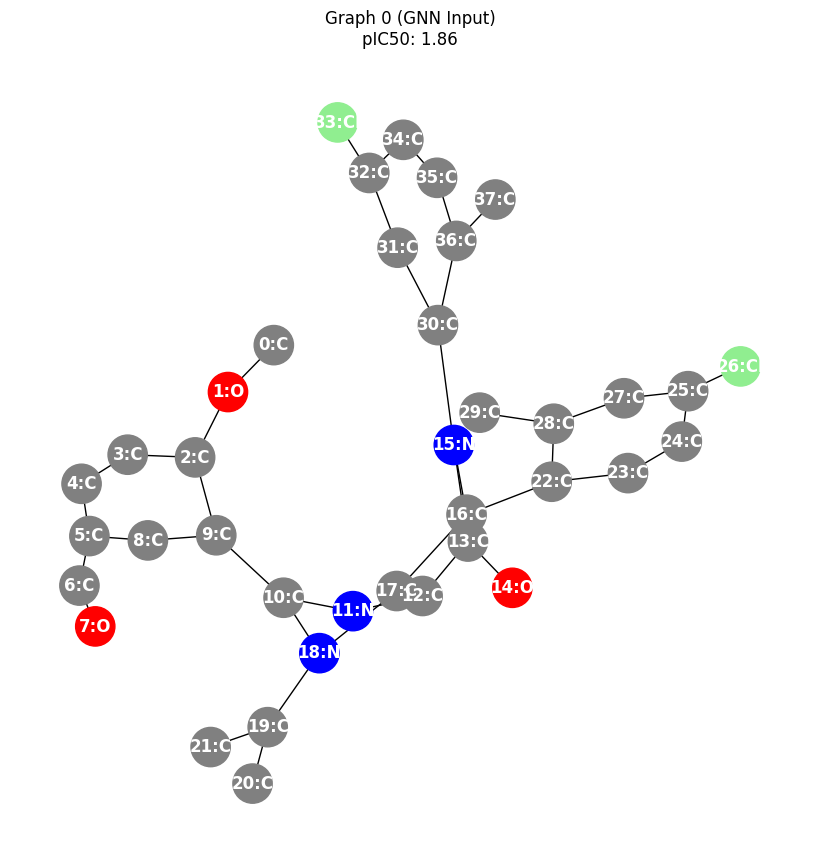

,SMILES,IC50,Target,Organism,IC50_numeric,pIC50,pIC50_norm
0,COc1ccc(CO)cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1c...,0.04,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.040,10.397940,1.862604
1,COc1ccc(cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1ccc(...,0.05,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.050,10.301030,1.799189
2,COC[C@@H](C)n1c(nc2C(=O)N([C@H](c12)c1ccc(Cl)c...,0.059,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152


In [8]:
mol_data = SmallMoleculeFeaturizer(root = os.path.join(ROOT, "data", "MDM2_Breaker"), file_path = mol_file)
df_mol = pd.read_csv(mol_data.processed_paths[0].replace('.pt', '.csv'))

visualize_graph(mol_data[0], title="Graph 0 (GNN Input)")
df_mol.head(3)

In [9]:
mol_data_v2 = SmallMoleculeFeaturizer_v2(root = os.path.join(ROOT, "data", "MDM2_Breaker"), file_path = mol_file)

## Prepare Data for Modeling

### Calculate Morgan Fingerprints

In [10]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
def smile_to_fingerprint(smile):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return np.zeros((2048,), dtype=np.float32)
    
    # NEW CALL
    fp = mfpgen.GetFingerprintAsNumPy(mol)
    return fp

df_mol["fingerprint"] = df_mol["SMILES"].apply(smile_to_fingerprint)
df_mol.head()


,SMILES,IC50,Target,Organism,IC50_numeric,pIC50,pIC50_norm,fingerprint
0,COc1ccc(CO)cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1c...,0.04,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.040,10.397940,1.862604,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,COc1ccc(cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1ccc(...,0.05,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.050,10.301030,1.799189,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
2,COC[C@@H](C)n1c(nc2C(=O)N([C@H](c12)c1ccc(Cl)c...,0.059,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
3,CC(C)(C)[C@@H](CS(=O)(=O)N1CCS(=O)(=O)CC1)N1[C...,0.059000,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,C[C@]1(CC(O)=O)C[C@@H]([C@H](N([C@H](CS(=O)(=O...,0.059000,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."


### Split Data into Train/Test/Val

In [11]:
torch.manual_seed(42) # Fixed seed for reproducibility
num_samples = len(mol_data)
indices = torch.randperm(num_samples).tolist()

train_size = int(0.8 * num_samples)
val_size = int(0.1 * num_samples)
test_size = num_samples - train_size - val_size

# Slice the Indices
train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

# Apply to the GNN Dataset
train_dataset = mol_data[train_indices]
val_dataset = mol_data[val_indices]
test_dataset = mol_data[test_indices]

# Apply to the GatCNN Dataset
train_dataset_v2 = mol_data_v2[train_indices]
val_dataset_v2 = mol_data_v2[val_indices]
test_dataset_v2 = mol_data_v2[test_indices]

# Apply to the CSV for XGBoost
train_df = df_mol.iloc[train_indices]
val_df = df_mol.iloc[val_indices]
test_df = df_mol.iloc[test_indices]

# Save the Data
train_df.to_csv(os.path.join(ROOT, "data", "MDM2_Breaker", "processed", "train_split.csv"), index=False)
val_df.to_csv(os.path.join(ROOT, "data", "MDM2_Breaker", "processed", "val_split.csv"), index=False)
test_df.to_csv(os.path.join(ROOT, "data", "MDM2_Breaker", "processed", "test_split.csv"), index=False)

# Create Loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=7, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=7, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=7, persistent_workers=True)

train_loader_v2 = DataLoader(train_dataset_v2, batch_size=batch_size, shuffle=True, num_workers=7, persistent_workers=True)
val_loader_v2 = DataLoader(val_dataset_v2, batch_size=batch_size, shuffle=False, num_workers=7, persistent_workers=True)
test_loader_v2 = DataLoader(test_dataset_v2, batch_size=batch_size, shuffle=False, num_workers=7, persistent_workers=True)

# INSPECTION BLOCK
batch = next(iter(train_loader))

# Get the Protein Graph (from your ProteinFeaturizer)
protein_graph = protein_data.get_graph()

# --- 2. Initialize System ---
sarcoma_system = SarcomaScoutSystem(protein_graph=protein_graph)
sarcoma_system_v2 = SarcomaScoutSystem_v2(protein_graph=protein_graph)


/Users/dantrainer/projects/cancer_research/src/mdm2_breaker/featurizers.py:89: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  edge_index = torch.tensor([src, dst], dtype=torch.long)


## Modeling

### XGBoost Baseline

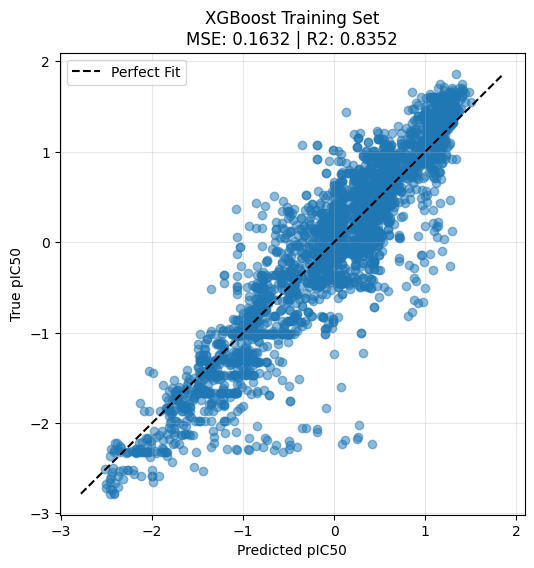

In [59]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

X_test = np.stack(np.array(test_df['fingerprint']))
y_test = test_df['pIC50_norm'].values
X_train = np.stack(np.array(train_df['fingerprint']))
y_train = train_df['pIC50_norm'].values
X_val = np.stack(np.array(val_df['fingerprint']))
y_val = val_df['pIC50_norm'].values

xgb_model.fit(X_train, y_train)

y_pred_train = xgb_model.predict(X_train)
y_pred_val = xgb_model.predict(X_val)
y_pred_test = xgb_model.predict(X_test)

mse_train = np.mean((y_pred_train - y_train) ** 2)
mse_val = np.mean((y_pred_val - y_val) ** 2)
mse_test = np.mean((y_pred_test - y_test) ** 2)

plot_xgboost_predictions(y_pred_train, y_train, "XGBoost Training Set", mse_train)


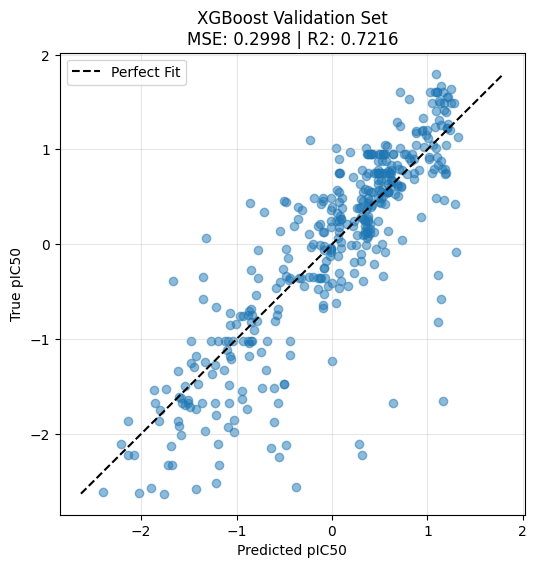

In [62]:
plot_xgboost_predictions(y_pred_val, y_val, "XGBoost Validation Set", mse_val)

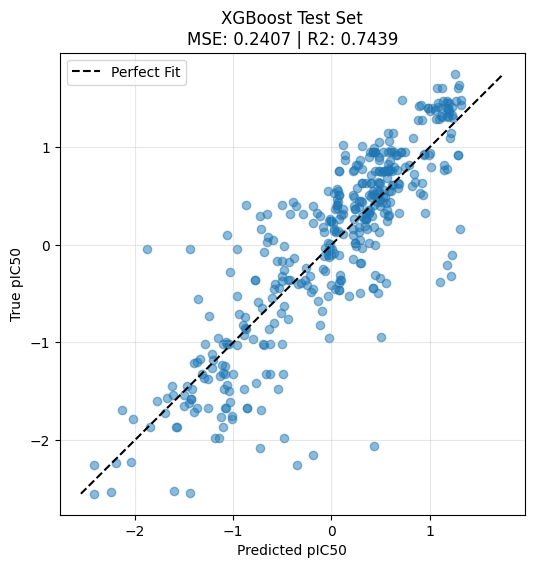

In [63]:
plot_xgboost_predictions(y_pred_test, y_test, "XGBoost Test Set", mse_test)

### Graph Network

In [15]:
# --- 3. Define Callbacks ---
# Checkpoint: Save the model with the lowest Validation Loss
checkpoint_cb = ModelCheckpoint(
    dirpath='checkpoints/',
    filename='sarcoma-model-{epoch:02d}-{val_loss:.2f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1
)

# Early Stopping: Stop if val_loss doesn't improve for 10 epochs
early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min'
)

lr_monitor = LearningRateMonitor(logging_interval='epoch')

# --- 4. Train! ---
trainer = pl.Trainer(
    max_epochs=100,
    accelerator='cpu', # Automatically finds your GPU (or M1 Metal)
    devices=1,
    callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
    log_every_n_steps=10
)

# trainer.fit(sarcoma_system, train_loader, val_loader)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


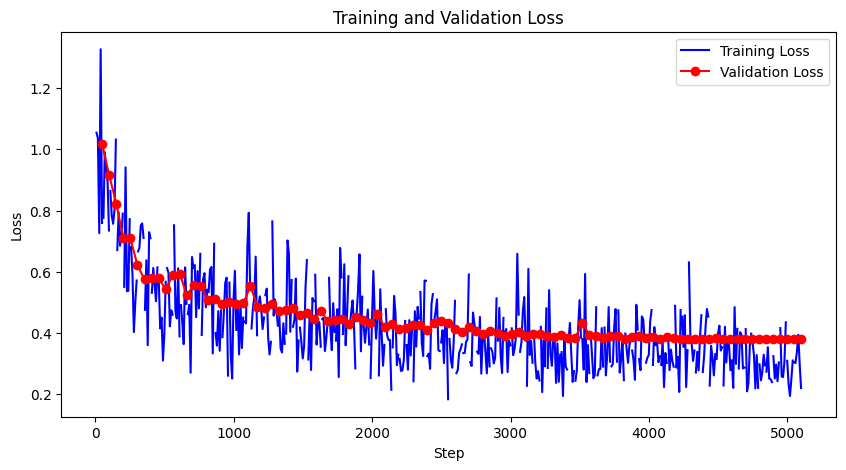

In [16]:
# read the training logs
df = pd.read_csv("lightning_logs/version_38/metrics.csv")
fix, ax = plt.subplots(figsize=(10, 5))
df.plot(x="step", y="train_loss", title="Training Loss", ax=ax, label="Training Loss", color="blue", legend=True, style="-",)
df.dropna(subset=["val_loss"]).plot(x="step", y="val_loss", title="Validation Loss", ax=ax, label="Validation Loss", color="red", legend=True, style="-o")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
plt.show()


In [35]:
# 1. Load the raw checkpoint
checkpoint = torch.load("checkpoints/sarcoma-model-epoch=90-val_loss=0.38.ckpt")
state_dict = checkpoint['state_dict']

# 2. Fix the keys (Remove "model." prefix)
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith("model."):
        # Strip the first 6 characters ("model.")
        new_key = key[6:]  
        new_state_dict[new_key] = value

# 3. Initialize your raw model
model = GraphSiameseNetwork(
    protein_in_channels=20,
    molecule_in_channels=9,
    out_channels=128,
    molecule_embedding_dim=64
)

# 4. Load the cleaned weights
model.load_state_dict(new_state_dict)
model.eval()

GraphSiameseNetwork(
  (protein_encoder): GCNEncoder(
    (conv1): GCNConv(20, 1024)
    (conv2): GCNConv(1024, 512)
    (conv3): GCNConv(512, 256)
    (conv4): GCNConv(256, 128)
  )
  (molecule_embedding): Embedding(9, 64)
  (molecule_encoder): GCNEncoder(
    (conv1): GCNConv(64, 1024)
    (conv2): GCNConv(1024, 512)
    (conv3): GCNConv(512, 256)
    (conv4): GCNConv(256, 128)
  )
  (attention_pool): AttentionalAggregation(gate_nn=Linear(in_features=128, out_features=1, bias=True), nn=None)
  (mlp): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

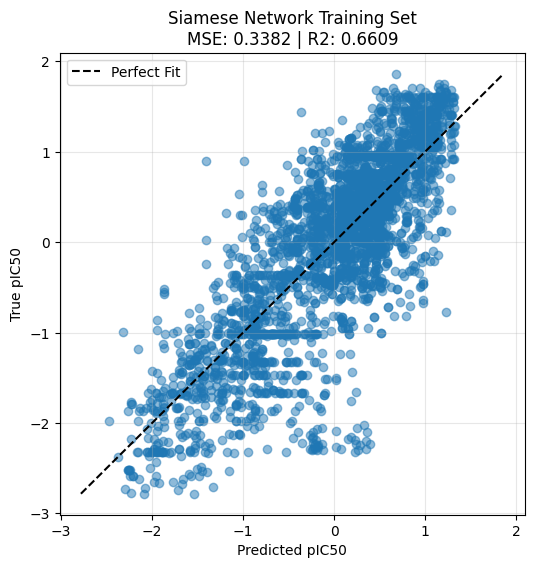

In [36]:
plot_predictions(model, train_loader, protein_graph, "Siamese Network Training Set")

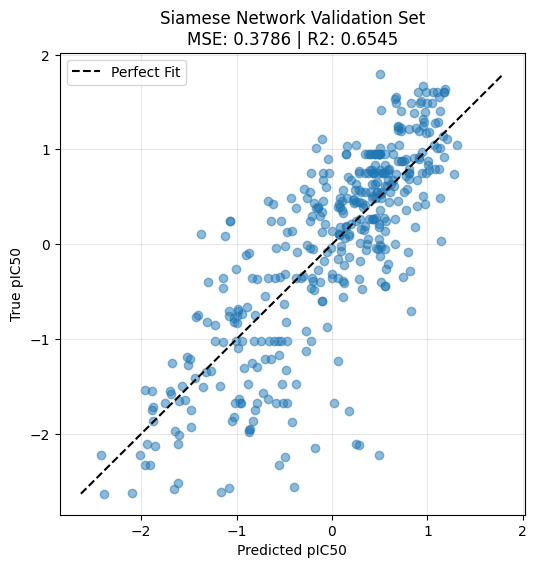

In [37]:
plot_predictions(model, val_loader, protein_graph, "Siamese Network Validation Set")

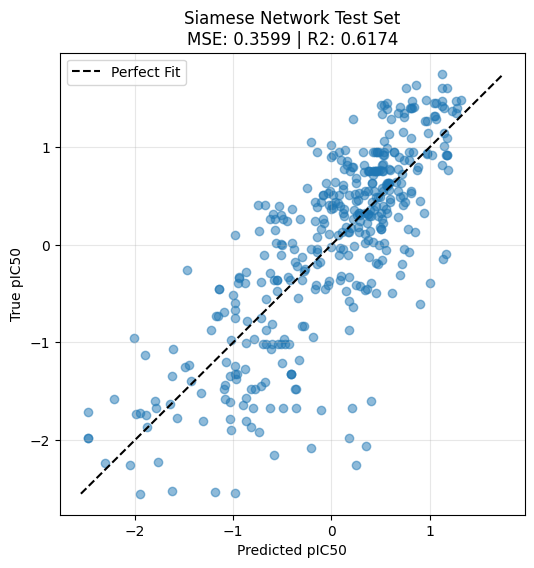

In [38]:
plot_predictions(model, test_loader, protein_graph, "Siamese Network Test Set")

### Graph Network v2

In [21]:
# --- 3. Define Callbacks ---
# Checkpoint: Save the model with the lowest Validation Loss
checkpoint_cb = ModelCheckpoint(
    dirpath='checkpoints/',
    filename='sarcoma-model-{epoch:02d}-{val_loss:.2f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1
)

# Early Stopping: Stop if val_loss doesn't improve for 10 epochs
early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min'
)

lr_monitor = LearningRateMonitor(logging_interval='epoch')

# --- 4. Train! ---
trainer = pl.Trainer(
    max_epochs=100,
    accelerator='cpu', # Automatically finds your GPU (or M1 Metal)
    devices=1,
    callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
    log_every_n_steps=10
)

trainer.fit(sarcoma_system_v2, train_loader_v2, val_loader_v2)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/dantrainer/projects/cancer_research/notebooks/checkpoints exists and is not empty.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ GraphSiameseNetwork_v2 │ 23.5 M │ train │     0 │
└───┴───────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 23.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.5 M                                                                                               
Total estimated model params size (MB): 93                                                                         
Modules in train mode: 44                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

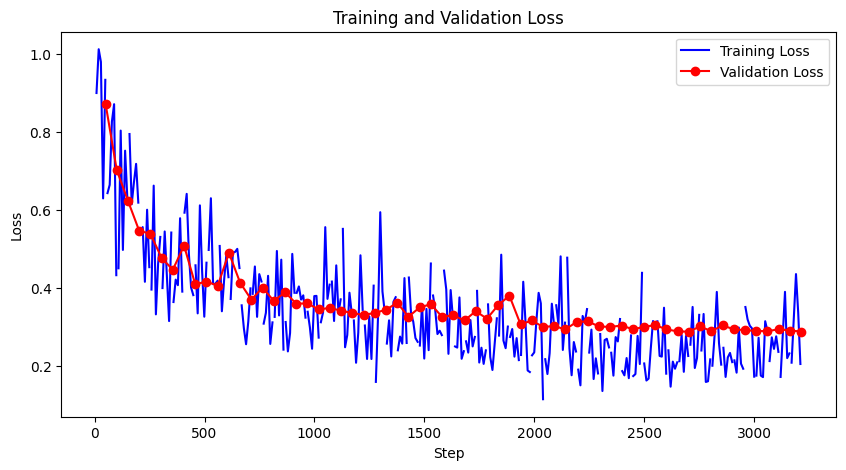

In [22]:
# read the training logs
df = pd.read_csv("lightning_logs/version_41/metrics.csv")
fix, ax = plt.subplots(figsize=(10, 5))
df.plot(x="step", y="train_loss", title="Training Loss", ax=ax, label="Training Loss", color="blue", legend=True, style="-",)
df.dropna(subset=["val_loss"]).plot(x="step", y="val_loss", title="Validation Loss", ax=ax, label="Validation Loss", color="red", legend=True, style="-o")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
plt.show()


In [39]:
# 1. Load the raw checkpoint
checkpoint = torch.load("checkpoints/sarcoma-model-epoch=52-val_loss=0.29.ckpt")
state_dict = checkpoint['state_dict']

# 2. Fix the keys (Remove "model." prefix)
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith("model."):
        # Strip the first 6 characters ("model.")
        new_key = key[6:]  
        new_state_dict[new_key] = value

# 3. Initialize your raw model
model = GraphSiameseNetwork_v2(
    protein_in_channels=20,
    molecule_in_channels=9,
    out_channels=128,
    molecule_embedding_dim=64
)

# 4. Load the cleaned weights
model.load_state_dict(new_state_dict)
model.eval()

GraphSiameseNetwork_v2(
  (protein_encoder): GCNEncoder(
    (conv1): GCNConv(20, 1024)
    (conv2): GCNConv(1024, 512)
    (conv3): GCNConv(512, 256)
    (conv4): GCNConv(256, 128)
  )
  (molecule_embedding): Embedding(9, 64)
  (molecule_encoder): GatCNEncoder(
    (conv1): GATv2Conv(64, 1024, heads=4)
    (conv2): GATv2Conv(4096, 512, heads=4)
    (conv3): GATv2Conv(2048, 256, heads=4)
    (conv4): GATv2Conv(1024, 128, heads=4)
  )
  (attention_pool): AttentionalAggregation(gate_nn=Linear(in_features=128, out_features=1, bias=True), nn=None)
  (mlp): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

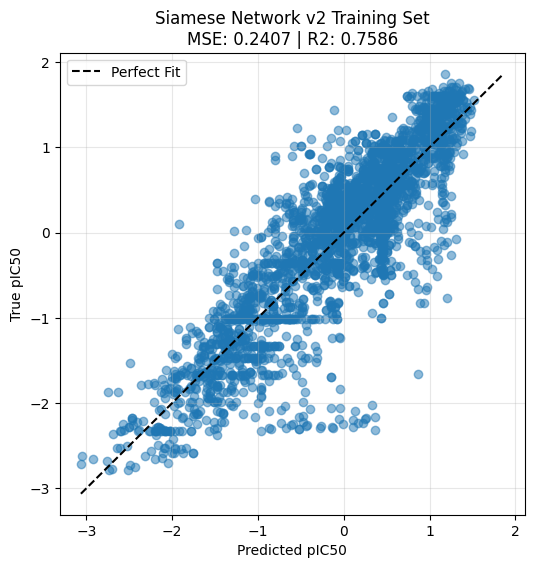

In [40]:
plot_predictions(model, train_loader_v2, protein_graph, "Siamese Network v2 Training Set")

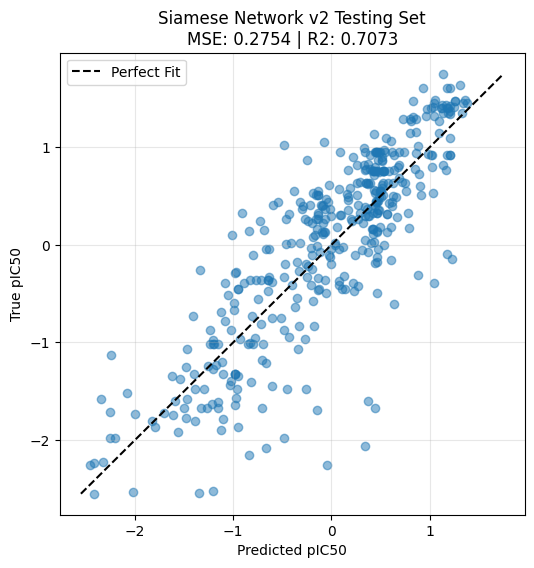

In [41]:
plot_predictions(model, test_loader_v2, protein_graph, "Siamese Network v2 Testing Set")

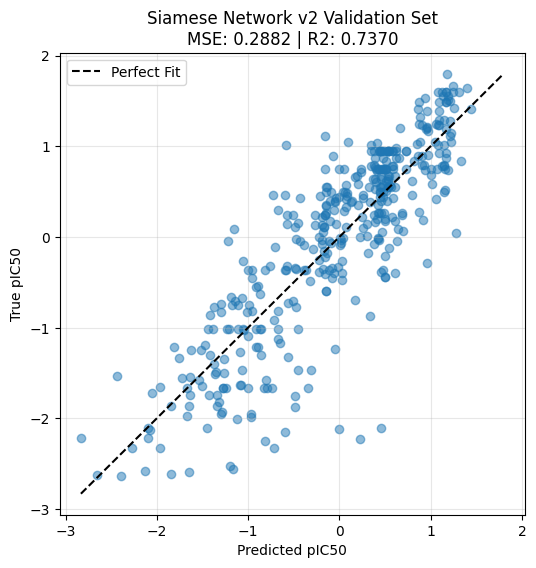

In [42]:
plot_predictions(model, val_loader_v2, protein_graph, "Siamese Network v2 Validation Set")